In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

RADNOM_STATE = 42

In [4]:
df = pd.read_csv("data/insurance_teaching.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges,age_copy
0,19,female,27.900,0,yes,southwest,16884.92400,37.866111
1,18,male,33.770,1,no,southeast,1725.55230,34.993021
2,28,male,33.000,3,no,southeast,4449.46200,54.703976
3,33,male,22.705,0,no,northwest,21984.47061,66.507081
4,32,male,28.880,0,no,northwest,3866.85520,64.597732


In [5]:
df.shape

(1458, 8)

In [6]:
df.isna().sum()

age           0
sex           0
bmi         158
children      0
smoker       41
region        0
charges       0
age_copy      0
dtype: int64

we will need to handle missing values

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,age,bmi,children,charges,age_copy
count,1458.000000,1300.000000,1458.000000,1458.000000,1458.000000
mean,39.212620,31.251715,1.109739,13598.491745,78.420785
std,14.056853,8.423439,1.208084,12493.659353,28.165817
min,18.000000,15.960000,0.000000,1121.873900,33.518014
25%,27.000000,26.315000,0.000000,4751.711700,52.666850
50%,39.000000,30.495000,1.000000,9494.108625,78.638965
75%,51.000000,34.800000,2.000000,17609.774570,102.400049
max,64.000000,85.000000,5.000000,71913.545250,129.444712


We need to handle outliers in features `charges` and `bmi`

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1458 non-null   int64  
 1   sex       1458 non-null   object 
 2   bmi       1300 non-null   float64
 3   children  1458 non-null   int64  
 4   smoker    1417 non-null   object 
 5   region    1458 non-null   object 
 6   charges   1458 non-null   float64
 7   age_copy  1458 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 91.3+ KB


In [10]:
df.children.value_counts()

children
0    616
1    355
2    265
3    175
4     27
5     20
Name: count, dtype: int64

In [11]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_copy'],
      dtype='object')

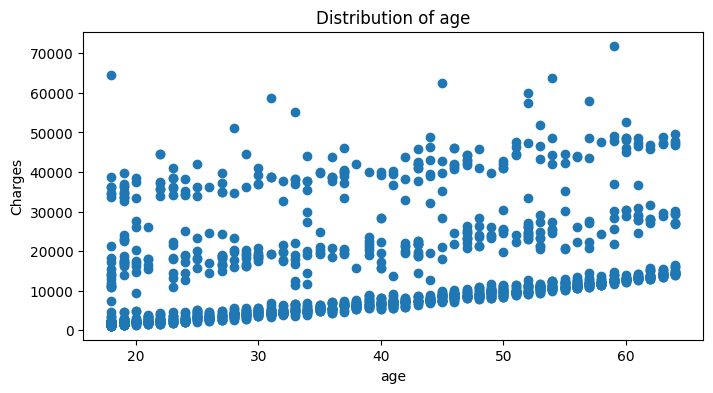

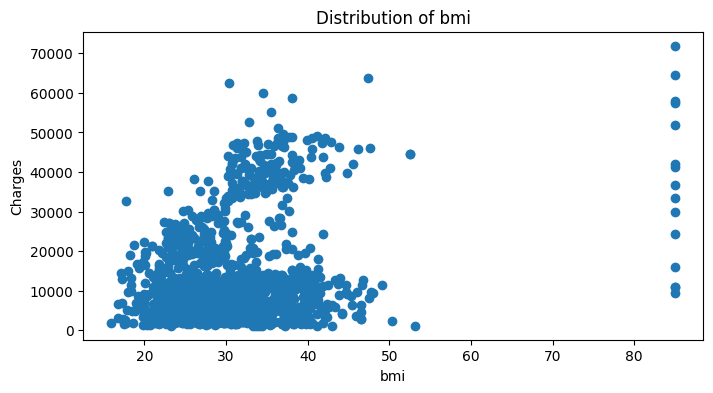

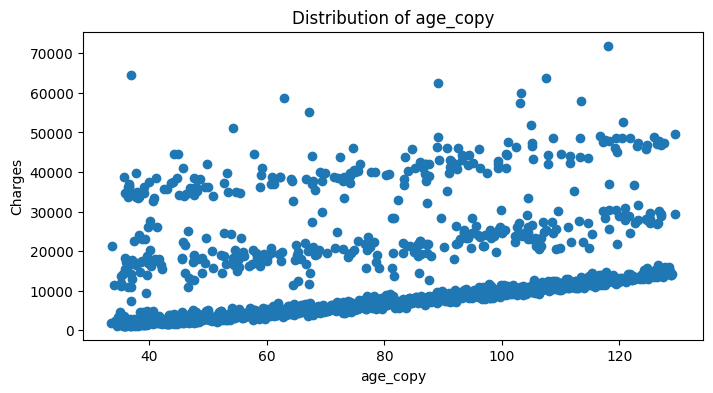

In [13]:
numerical_features = ['age', 'bmi', 'age_copy']

for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    plt.scatter(df[feature], df['charges'])
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Charges')
    plt.show()

<Axes: xlabel='age', ylabel='charges'>

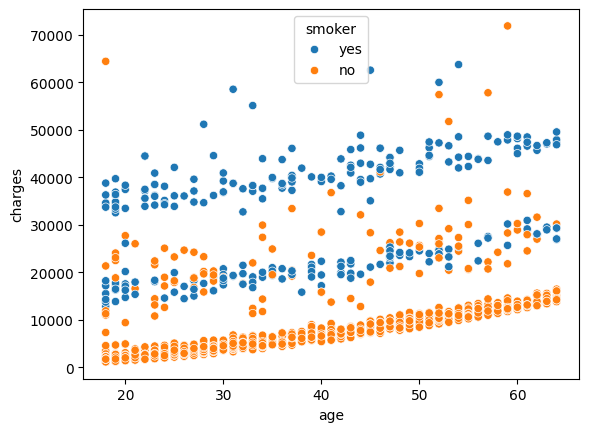

In [14]:
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")

<Axes: xlabel='bmi', ylabel='charges'>

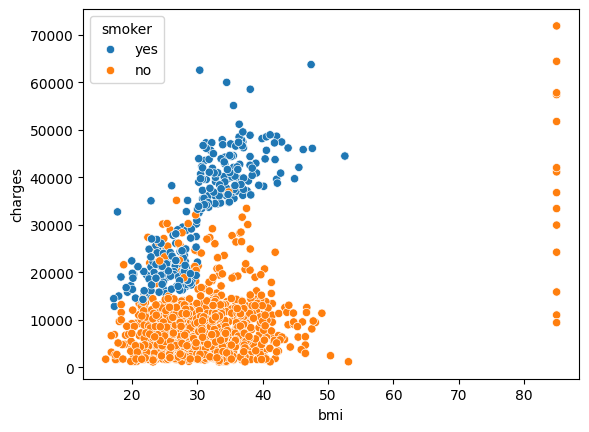

In [16]:
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")

<Axes: >

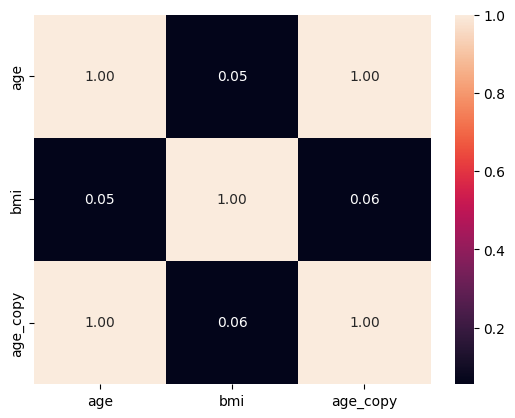

In [19]:
sns.heatmap(df[numerical_features].corr(), annot=True, fmt="0.2f")

Correlation between `age` and `age_copy` is 1.0 ==> multicollinearity issue

In [20]:
x = df.drop(columns="charges")
y = df["charges"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=RADNOM_STATE)

In [25]:
results = []
def evaluate_regression(exp_name, model, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    results.append({
        'Experiment': exp_name,
        'MSE': mean_squared_error(y_test, y_pred),
        "R2 Score": r2_score(y_test, y_pred)
    })
    return pd.DataFrame(results).round(3)

# Imputation + OneHotEncoding

In [22]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_copy'],
      dtype='object')

In [23]:
cat_features = ['sex', 'smoker', 'region', 'children']
baseline_preprocessor = ColumnTransformer([
    ('numerical', SimpleImputer(strategy="mean"), numerical_features),  # numerical features
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy="most_frequent")),  # categorical features
        ('encoder', OneHotEncoder())
    ]), cat_features)  # categorical data
])

In [26]:
baseline_model = Pipeline([
    ('preprocessor', baseline_preprocessor),
    ('regressor', LinearRegression())
])

evaluate_regression("Baseline Model", baseline_model, x_train, x_test, y_train, y_test)

,Experiment,MSE,R2 Score
0,Baseline Model,45483920.73,0.714


# Outliers

<Axes: xlabel='bmi'>

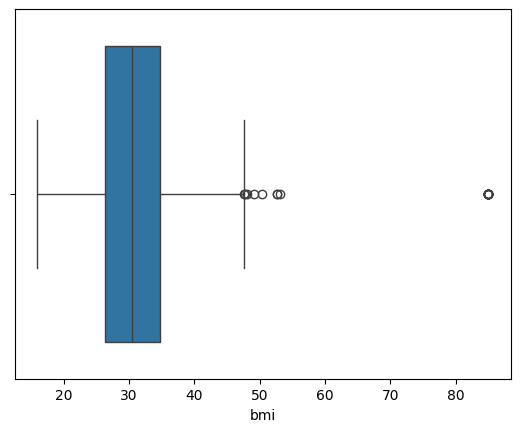

In [27]:
sns.boxplot(data=df, x="bmi")

In [28]:
numerical_features

['age', 'bmi', 'age_copy']

<Axes: xlabel='age'>

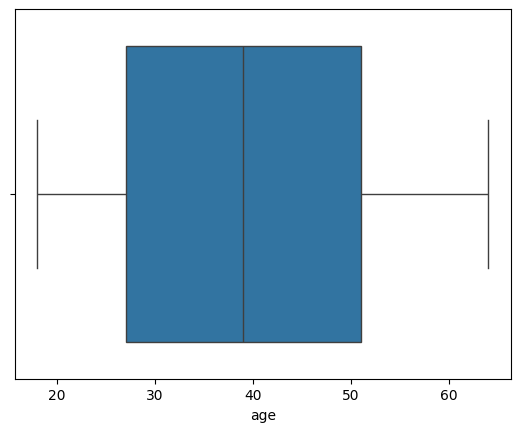

In [29]:
sns.boxplot(data=df, x="age")

In [30]:
q1 = x_train['bmi'].quantile(0.25)
q3 = x_train['bmi'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

In [31]:
x_train_capped = x_train.copy()
x_test_capped = x_test.copy()
x_train_capped['bmi'] = x_train_capped['bmi'].clip(lower, upper)
x_test_capped['bmi'] = x_test_capped['bmi'].clip(lower, upper)

evaluate_regression("Capped BMI Model", baseline_model, x_train_capped, x_test_capped, y_train, y_test)

,Experiment,MSE,R2 Score
0,Baseline Model,4.548392e+07,0.714
1,Capped BMI Model,4.761168e+07,0.700


# scaling

In [32]:
df.head()

,age,sex,bmi,children,smoker,region,charges,age_copy
0,19,female,27.900,0,yes,southwest,16884.92400,37.866111
1,18,male,33.770,1,no,southeast,1725.55230,34.993021
2,28,male,33.000,3,no,southeast,4449.46200,54.703976
3,33,male,22.705,0,no,northwest,21984.47061,66.507081
4,32,male,28.880,0,no,northwest,3866.85520,64.597732


In [37]:
numerical_features

['age', 'bmi', 'age_copy']

In [34]:
baseline_preprocessor = ColumnTransformer([
    ('numerical', Pipeline([
        ('imputer', SimpleImputer(strategy="mean")),
        ('standard_scaler', StandardScaler())
    ]), numerical_features),  # numerical features
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy="most_frequent")),  # categorical features
        ('encoder', OneHotEncoder())
    ]), cat_features)  # categorical data
])

In [36]:
scaled_plr = Pipeline([
    ('preprocessor', baseline_preprocessor),
    ('regressor', LinearRegression())
])

evaluate_regression("Scaled Baseline Model", scaled_plr, x_train, x_test, y_train, y_test)

,Experiment,MSE,R2 Score
0,Baseline Model,4.548392e+07,0.714
1,Capped BMI Model,4.761168e+07,0.700
2,Baseline Model,4.548392e+07,0.714
3,Scaled Baseline Model,4.548392e+07,0.714


# multicollinearity

In [39]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_copy'],
      dtype='object')

In [42]:
num_demo = df[['age', 'charges', 'age_copy']].copy()
x_demo = num_demo[['age', 'age_copy']]
y_demo = num_demo['charges']

xtr, xte, ytr, yte = train_test_split(x_demo, y_demo, test_size=0.2, random_state=RADNOM_STATE)
model_both = LinearRegression().fit(xtr, ytr)
model_age = LinearRegression().fit(xtr[['age']], ytr)

In [44]:
model_both.coef_

array([ 654.11413818, -195.21450381])

In [45]:
model_age.coef_

array([262.77609437])

In [48]:
x_train

,age,sex,bmi,children,smoker,region
254,50,male,31.825,0,yes,northeast
1065,42,female,25.300,1,no,southwest
864,51,male,25.400,0,no,southwest
798,58,female,NaN,0,no,southwest
380,27,female,17.955,2,yes,northeast
...,...,...,...,...,...,...
1095,18,female,31.350,4,no,northeast
1130,39,female,23.870,5,no,southeast
1294,58,male,25.175,0,no,northeast
860,37,female,47.600,2,yes,southwest


In [49]:
x_test

,age,sex,bmi,children,smoker,region
1320,31,male,31.065,3,no,northwest
836,36,male,31.500,0,no,southwest
413,25,male,NaN,5,no,southwest
522,51,female,33.915,0,no,northeast
1035,54,female,23.000,3,no,southwest
...,...,...,...,...,...,...
479,23,male,32.560,0,no,southeast
1359,43,male,NaN,2,no,southwest
1413,36,female,NaN,0,no,southeast
650,49,female,NaN,2,no,southeast


In [50]:
# pipeline
# x_train = x_train.drop(columns=['age_copy'])
# x_test = x_test.drop(columns=['age_copy'])

num_features_noagecopy = ["age", "bmi"]
preprocessor_noagecopy = ColumnTransformer([
    ('numerical', SimpleImputer(strategy="mean"), num_features_noagecopy),  # numerical features
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy="most_frequent")),  # categorical features
        ('encoder', OneHotEncoder())
    ]), cat_features)  # categorical data
])

lr_no_agecopy = Pipeline([
    ('preprocessor', preprocessor_noagecopy),
    ('model', LinearRegression())
])

evaluate_regression("Remove age copy", lr_no_agecopy, x_train, x_test, y_train, y_test)

,Experiment,MSE,R2 Score
0,Baseline Model,4.548392e+07,0.714
1,Capped BMI Model,4.761168e+07,0.700
2,Baseline Model,4.548392e+07,0.714
3,Scaled Baseline Model,4.548392e+07,0.714
4,Remove age copy,4.548164e+07,0.714
